In [ ]:
!cat /etc/*release

DISTRIB_ID=Ubuntu
DISTRIB_RELEASE=22.04
DISTRIB_CODENAME=jammy
DISTRIB_DESCRIPTION="Ubuntu 22.04.3 LTS"
PRETTY_NAME="Ubuntu 22.04.3 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.3 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [11]:
!pip install ultralytics

In [12]:
#Import libs
import ultralytics
import random
import os
from google.colab import drive
from matplotlib import pyplot as plt
import numpy as np

In [3]:
!pip freeze > requirements.txt

In [4]:
#Mount drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = "/content/drive/MyDrive/Universidad/Tesis/Datasets/dataset"

In [6]:
pathModel = "/content/drive/MyDrive/Universidad/Tesis/Código/TrainedModels"

In [ ]:
def randomVisualization(path,dataset='train'):
  image = random.choice(os.listdir(path+"/data/"+dataset+"/images"))
  label = image.replace(".JPG", ".txt")
  img = plt.imread(path+"/data/"+dataset+"/images/"+image)
  dim = img.shape
  fig, ax = plt.subplots(1,2, figsize=(10,10))

  labels = ["Tronco","1 año","2 años","3 años o más"]
  colors = ['red','green','yellow','orange']
  lines = []
  with open(path+"/data/"+dataset+"/labels/"+label, "r") as f:
    lines = f.readlines()
  for line in lines:
    coordX = []
    coordY = []
    line = line.split(" ")
    id = int(line[0])
    for i in range(1, len(line)):
      if float(line[i]) == 2.0:
        coordX.append(float(line[i-2])*dim[1])
        coordY.append(float(line[i-1])*dim[0])
    ax[1].plot(coordX, coordY, color = colors[id] ,linewidth=1, marker='o',markersize=2)
  fig.suptitle("Imagen "+image.replace(".JPG","")+" del conjunto "+dataset)
  ax[0].set_title("Original")
  ax[0].axis('off')
  ax[0].imshow(img)
  for i in range(4):
    ax[1].plot([], [], label=labels[i],color=colors[i])
  ax[1].set_title("Etiquetada")
  ax[1].axis('off')
  ax[1].legend()
  ax[1].imshow(img)

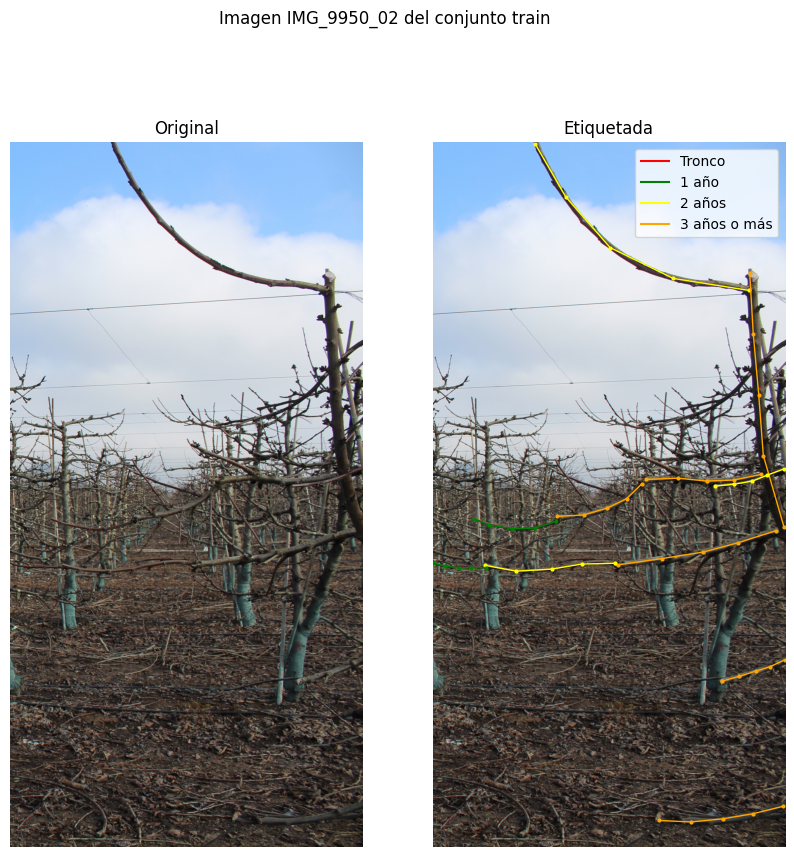

In [ ]:
randomVisualization(path)

In [ ]:
model = ultralytics.YOLO(pathModel+'/YOLOv11m_batch16_size800_epochs200_last.pt')  # build a new model from YAML

In [ ]:
model = ultralytics.YOLO(pathModel+'/YOLOv11n_batch16_size800_epochs200_best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=800, batch=16,device="0",plots=True, split="test")

Ultralytics 8.3.48 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11n-pose summary (fused): 257 layers, 2,655,217 parameters, 0 gradients, 6.6 GFLOPs


val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:04<00:00,  4.49s/it]


                   all          5        240      0.292      0.184      0.133       0.05       0.28      0.178      0.133     0.0595
                 trunk          4          5       0.36        0.4      0.174     0.0422      0.357        0.4      0.194     0.0536
              1yearold          5         22      0.118     0.0909       0.07     0.0426      0.116     0.0909     0.0817     0.0612
              2yearold          5        103       0.32     0.0824      0.132     0.0511      0.363      0.094      0.141     0.0704
        3ormoreyearold          5        110       0.37      0.164      0.155     0.0641      0.285      0.127      0.115      0.053
Speed: 0.2ms preprocess, 6.9ms inference, 0.0ms loss, 6.0ms postprocess per image
Results saved to runs/pose/val2


In [ ]:
model = ultralytics.YOLO(pathModel+'/YOLOv11s_batch16_size800_epochs200_best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=800, batch=16,device="0",plots=True, split="test")

Ultralytics 8.3.48 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11s-pose summary (fused): 257 layers, 9,701,721 parameters, 0 gradients, 22.3 GFLOPs


val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.53it/s]


                   all          5        240      0.291      0.223      0.161     0.0738      0.296      0.223      0.163     0.0961
                 trunk          4          5      0.369        0.4      0.209     0.0929       0.37        0.4      0.209      0.119
              1yearold          5         22      0.123      0.136     0.0888     0.0603      0.124      0.136     0.0931     0.0799
              2yearold          5        103      0.325      0.136      0.145     0.0558      0.372      0.155       0.17     0.0894
        3ormoreyearold          5        110      0.345      0.218      0.202     0.0863      0.319        0.2      0.179     0.0959
Speed: 0.2ms preprocess, 19.5ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to runs/pose/val3


In [ ]:
model = ultralytics.YOLO(pathModel+'/YOLOv11m_batch16_size800_epochs200_best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=800, batch=12,device="0",plots=True, split="test")

Ultralytics 8.3.48 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11m-pose summary (fused): 322 layers, 20,884,297 parameters, 0 gradients, 71.4 GFLOPs


val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


                   all          5        240      0.283      0.189      0.157     0.0855      0.373      0.257        0.2      0.129
                 trunk          4          5      0.247        0.2     0.0956     0.0365      0.494      0.393      0.208      0.119
              1yearold          5         22      0.111      0.136     0.0851     0.0729      0.218      0.227      0.132     0.0907
              2yearold          5        103      0.387      0.136      0.199      0.105      0.389      0.126      0.199      0.139
        3ormoreyearold          5        110      0.387      0.282       0.25      0.127      0.392      0.282      0.262      0.166
Speed: 0.2ms preprocess, 32.0ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/pose/val4


In [ ]:
model = ultralytics.YOLO(pathModel+'/YOLOv11l_batch12_size608_epochs200_best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=608, batch=4,device="0",plots=True, split="test")

Ultralytics 8.3.48 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11l-pose summary (fused): 483 layers, 26,133,577 parameters, 0 gradients, 90.3 GFLOPs


val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.47it/s]


                   all          5        240      0.339      0.145      0.175     0.0917       0.35      0.234      0.233      0.111
                 trunk          4          5      0.284        0.2      0.203      0.122      0.346        0.4      0.334      0.089
              1yearold          5         22      0.115      0.136     0.0887     0.0705      0.108      0.182      0.109     0.0829
              2yearold          5        103      0.479     0.0874      0.179     0.0754      0.463      0.117        0.2      0.105
        3ormoreyearold          5        110      0.479      0.155      0.231     0.0989      0.483      0.238       0.29      0.169
Speed: 3.8ms preprocess, 50.3ms inference, 0.0ms loss, 9.6ms postprocess per image
Results saved to runs/pose/val3


In [ ]:
model = ultralytics.YOLO(pathModel+'/YOLOv11x_batch4_size400_epochs200_best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=400, batch=16,device="0",plots=True, split="test")

Ultralytics 8.3.48 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11x-pose summary (fused): 483 layers, 58,744,297 parameters, 0 gradients, 202.7 GFLOPs


val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.24it/s]


                   all          5        240      0.213      0.296      0.124     0.0588      0.228      0.293      0.156     0.0851
                 trunk          4          5      0.122        0.4      0.061     0.0239      0.127        0.4      0.142     0.0587
              1yearold          5         22      0.117      0.273     0.0648     0.0294      0.119      0.257     0.0789     0.0505
              2yearold          5        103      0.315      0.194      0.177     0.0913      0.366      0.214      0.205      0.134
        3ormoreyearold          5        110      0.298      0.316      0.194     0.0907        0.3        0.3      0.198     0.0971
Speed: 0.3ms preprocess, 59.3ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to runs/pose/val6


In [ ]:
model = ultralytics.YOLO(pathModel+'/YOLOv11x_batch4_size400_epochs200_best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=400, batch=16,device="0",plots=True, split="test")

WARNING ⚠️ imgsz=[400] must be multiple of max stride 32, updating to [416]
Ultralytics 8.3.48 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11x-pose summary (fused): 483 layers, 58,744,297 parameters, 0 gradients, 202.7 GFLOPs


val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.66it/s]


                   all          5        240      0.215      0.224      0.184     0.0885      0.501      0.201      0.248      0.139
                 trunk          4          5       0.14        0.2      0.251      0.167      0.792        0.4      0.507      0.271
              1yearold          5         22     0.0454      0.136     0.0186    0.00877      0.078     0.0909     0.0255     0.0129
              2yearold          5        103      0.337      0.252      0.205     0.0768        0.6      0.155      0.231      0.136
        3ormoreyearold          5        110      0.338      0.309      0.262      0.101      0.534      0.156       0.23      0.138
Speed: 0.2ms preprocess, 29.5ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/pose/val2


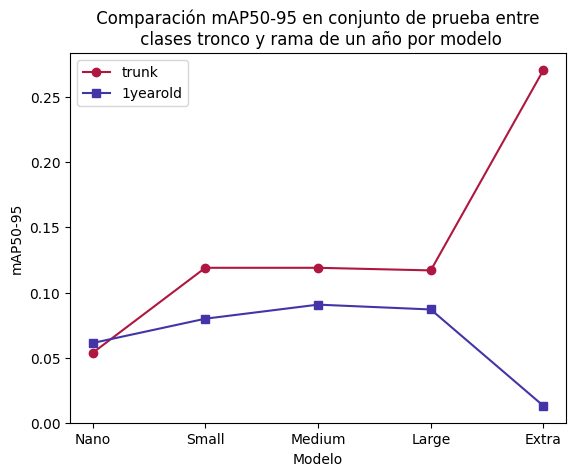

In [ ]:

# create data
xtronco = [0.0536,0.119,0.119,0.117,0.271]
x1yo = [0.0612,0.0799,0.0907,0.087,0.0129]
y = ['Nano','Small','Medium',"Large","Extra"]

plt.plot(y,xtronco,  label = "trunk",color='#AF1740',marker='o')
plt.plot(y,x1yo,  label = "1yearold",color='#4335A7',marker='s')
# plot lines
plt.xlabel("Modelo")
plt.ylabel("mAP50-95")
plt.legend()
plt.title(" Comparación mAP50-95 en conjunto de prueba entre \n clases tronco y rama de un año por modelo")
plt.show()

In [ ]:
model = ultralytics.YOLO(pathModel+'/nano1312best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=1312, batch=16,plots=True, split="test")

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-pose summary (fused): 257 layers, 2,655,217 parameters, 0 gradients, 6.6 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 15.0MB/s]
val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:06<00:00,  6.78s/it]


                   all          5        240      0.225      0.187      0.118     0.0593      0.259      0.234      0.175      0.075
                 trunk          4          5      0.129        0.2     0.0415      0.029      0.267        0.4      0.275     0.0799
              1yearold          5         22     0.0956      0.136     0.0836      0.059     0.0965      0.136     0.0969      0.077
              2yearold          5        103      0.376      0.175      0.179     0.0844      0.377       0.17      0.172     0.0843
        3ormoreyearold          5        110        0.3      0.236      0.167     0.0646      0.296      0.229      0.157     0.0587
Speed: 15.1ms preprocess, 584.4ms inference, 0.0ms loss, 33.8ms postprocess per image
Results saved to runs/pose/val2


In [ ]:
model = ultralytics.YOLO(pathModel+'/nano416best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=416, batch=16,plots=True, split="test")

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-pose summary (fused): 257 layers, 2,655,217 parameters, 0 gradients, 6.6 GFLOPs


val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


                   all          5        240      0.165      0.151       0.11     0.0551      0.217      0.228      0.204     0.0753
                 trunk          4          5      0.102        0.2      0.219      0.153      0.317        0.6      0.631      0.231
              1yearold          5         22     0.0966      0.136     0.0221     0.0066     0.0533     0.0619      0.031     0.0109
              2yearold          5        103      0.277     0.0874     0.0867     0.0284       0.32     0.0874     0.0844     0.0327
        3ormoreyearold          5        110      0.185      0.182      0.113     0.0322      0.176      0.164     0.0713      0.027
Speed: 0.6ms preprocess, 91.9ms inference, 0.0ms loss, 23.6ms postprocess per image
Results saved to runs/pose/val9


In [ ]:
model = ultralytics.YOLO(pathModel+'/nano224best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=224, batch=16,plots=True, split="test")

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-pose summary (fused): 257 layers, 2,655,217 parameters, 0 gradients, 6.6 GFLOPs


val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.32it/s]


                   all          5        240      0.159      0.185      0.106     0.0584      0.153      0.176     0.0823     0.0202
                 trunk          4          5      0.282        0.4      0.299      0.203      0.277        0.4       0.16      0.039
              1yearold          5         22     0.0701      0.136     0.0253    0.00348     0.0672      0.136     0.0789     0.0143
              2yearold          5        103      0.168     0.0291     0.0313     0.0101      0.178     0.0316     0.0305     0.0107
        3ormoreyearold          5        110      0.118      0.173     0.0674     0.0174     0.0888      0.136     0.0598     0.0168
Speed: 0.1ms preprocess, 32.4ms inference, 0.0ms loss, 6.7ms postprocess per image
Results saved to runs/pose/val7


In [ ]:
model = ultralytics.YOLO(pathModel+'/nano128best.pt')  # build a new model from YAML
validation_results = model.val(data=path+"/data.yaml", imgsz=128, batch=16,plots=True, split="test")

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n-pose summary (fused): 257 layers, 2,655,217 parameters, 0 gradients, 6.6 GFLOPs


val: Scanning /content/drive/MyDrive/Universidad/Tesis/Datasets/dataset/data/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.53it/s]


                   all          5        240     0.0798      0.107     0.0786     0.0439      0.115      0.102     0.0858     0.0537
                 trunk          4          5      0.225        0.4      0.276      0.166      0.386        0.4      0.309      0.205
              1yearold          5         22          0          0    0.00428   0.000721          0          0    0.00435    0.00103
              2yearold          5        103          0          0    0.00906    0.00261          0          0     0.0191    0.00562
        3ormoreyearold          5        110     0.0945     0.0273     0.0252    0.00624     0.0718    0.00909     0.0107    0.00315
Speed: 0.1ms preprocess, 18.5ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/pose/val8


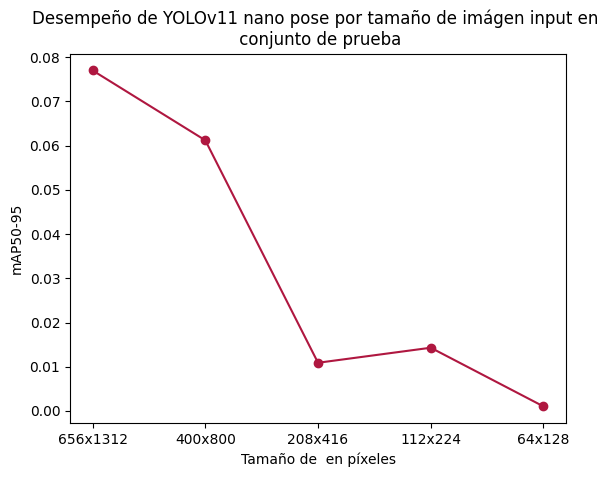

In [ ]:
# create data
map = [0.077,0.0612,0.0109,0.0143,0.00103]


sizes = ['656x1312','400x800','208x416','112x224','64x128']

plt.plot(sizes,map,color='#AF1740',marker='o')
# plot lines
plt.xlabel("Tamaño de  en píxeles")
plt.ylabel("mAP50-95")
plt.title("Desempeño de YOLOv11 nano pose por tamaño de imágen input en \n conjunto de prueba")
plt.show()

In [10]:
from PIL import Image
image = Image.open(path+'/data/train/images/IMG_9958_00.JPG')
image.save('image_original.jpg')
new_image = image.resize((656 , 1312))
new_image.save('image_1312.jpg')
new_image = image.resize((400 , 800))
new_image.save('image_800.jpg')
new_image = image.resize((208 , 416))
new_image.save('image_416.jpg')
new_image = image.resize((112 , 224))
new_image.save('image_224.jpg')
new_image = image.resize((64 , 128))
new_image.save('image_128.jpg')

In [15]:
model = ultralytics.YOLO(pathModel+'/YOLOv11x_batch4_size400_epochs200_best.pt')

In [27]:
results = model([path+'/data/test/images/IMG_9757_01.JPG'])


0: 608x320 2 trunks, 2 1yearolds, 4 2yearolds, 22 3ormoreyearolds, 1863.7ms
Speed: 3.8ms preprocess, 1863.7ms inference, 1.2ms postprocess per image at shape (1, 3, 608, 320)


In [28]:
#dir(results[0].verbose)
results[0].verbose()

'2 trunks, 2 1yearolds, 4 2yearolds, 22 3ormoreyearolds, '

In [36]:
results[0].boxes.cls.tolist()

[2.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 2.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 0.0,
 3.0,
 1.0,
 3.0,
 3.0,
 2.0,
 2.0,
 3.0,
 3.0,
 3.0,
 0.0,
 3.0,
 1.0,
 3.0,
 3.0,
 3.0]

In [43]:
results[0].keypoints.xyn.tolist()

[[[0.30517199635505676, 0.3001754581928253],
  [0.2903599143028259, 0.29070407152175903],
  [0.27750635147094727, 0.2804110050201416],
  [0.2646154761314392, 0.2694641947746277],
  [0.25524193048477173, 0.25446751713752747]],
 [[0.5849847197532654, 0.17399071156978607],
  [0.6969857215881348, 0.1682051569223404],
  [0.8111708164215088, 0.1755160540342331],
  [0.9165633320808411, 0.184816375374794],
  [1.0, 0.1910049468278885]],
 [[0.5085862278938293, 0.2944837212562561],
  [0.3813088834285736, 0.3059503436088562],
  [0.24705655872821808, 0.3106769323348999],
  [0.12264224141836166, 0.2983842194080353],
  [0.002710543340072036, 0.2720873951911926]],
 [[0.4138955771923065, 0.5698569416999817],
  [0.32729801535606384, 0.5895268321037292],
  [0.2265712022781372, 0.6130843758583069],
  [0.11716124415397644, 0.622068464756012],
  [0.0064164213836193085, 0.6204014420509338]],
 [[0.4802263677120209, 0.19615238904953003],
  [0.4300934076309204, 0.2075555920600891],
  [0.3845747411251068, 0.2194

In [94]:
def predictImage(model,image):
  img = plt.imread(image)
  results = model([image],verbose=False)
  clases = results[0].boxes.cls.tolist()
  branches = results[0].keypoints.xyn.tolist()
  dim = img.shape
  fig, ax = plt.subplots(1,2, figsize=(10,10))
  labels = ["Tronco","1 año","2 años","3 años o más"]
  colors = ['red','green','yellow','orange']
  for branch in branches:
    coordX = []
    coordY = []
    id = int(clases[branches.index(branch)])
    for i in range(len(branch)):
      coordX.append(branch[i][0]*dim[1])
      coordY.append(branch[i][1]*dim[0])
    ax[1].plot(coordX, coordY, color = colors[id] ,linewidth=1, marker='o',markersize=2)
  instances = results[0].verbose().split()
  instancesProcessed = {'trunk':'0','1yearold':'0','2yearold':'0','3ormoreyearold':'0'}
  for i in range(len(instances)):
    if not i%2 == 0:
      if instances[i][0] == 't':
        instancesProcessed['trunk'] = instances[i-1]
      elif instances[i][0] == '1':
        instancesProcessed['1yearold'] = instances[i-1]
      elif instances[i][0] == '2':
        instancesProcessed['2yearold'] = instances[i-1]
      elif instances[i][0] == '3':
        instancesProcessed['3ormoreyearold'] = instances[i-1]
  title = image.replace(".JPG","")
  lastindex = title.rfind("/")
  title = title[lastindex+1:]
  fig.suptitle("Predicción de imágen "+title)
  ax[0].set_title("Original")
  ax[0].axis('off')
  ax[0].imshow(img)
  for i in range(4):
    ax[1].plot([], [], label=labels[i]+" ("+instancesProcessed[list(instancesProcessed.keys())[i]]+")",color=colors[i])
  ax[1].set_title("Etiquetada")
  ax[1].axis('off')
  ax[1].legend()
  ax[1].imshow(img)

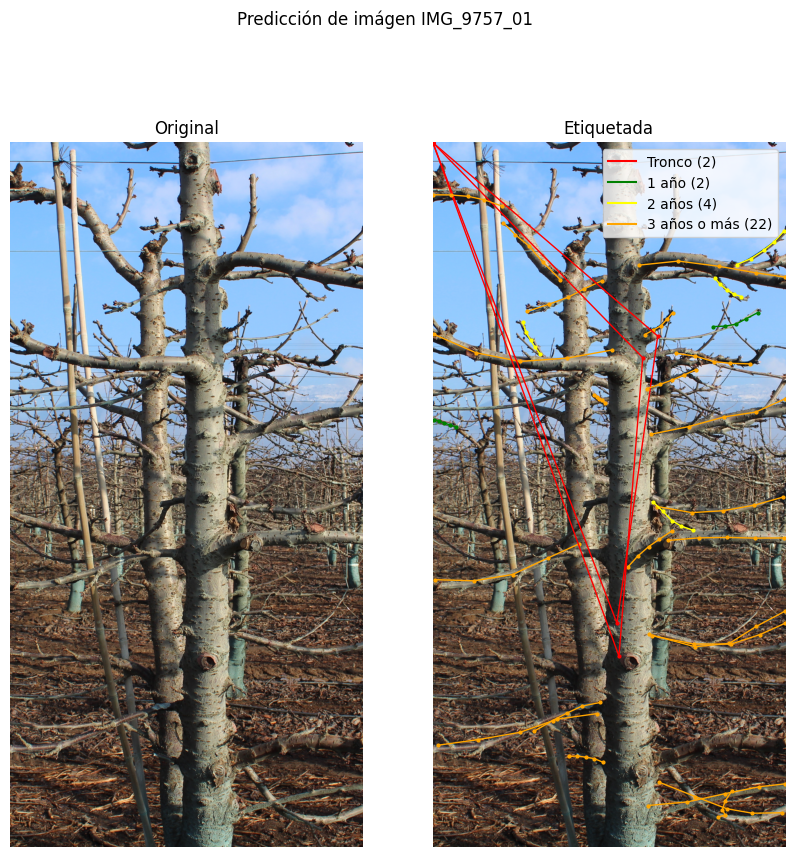

In [95]:
predictImage(model,path+'/data/test/images/IMG_9757_01.JPG')

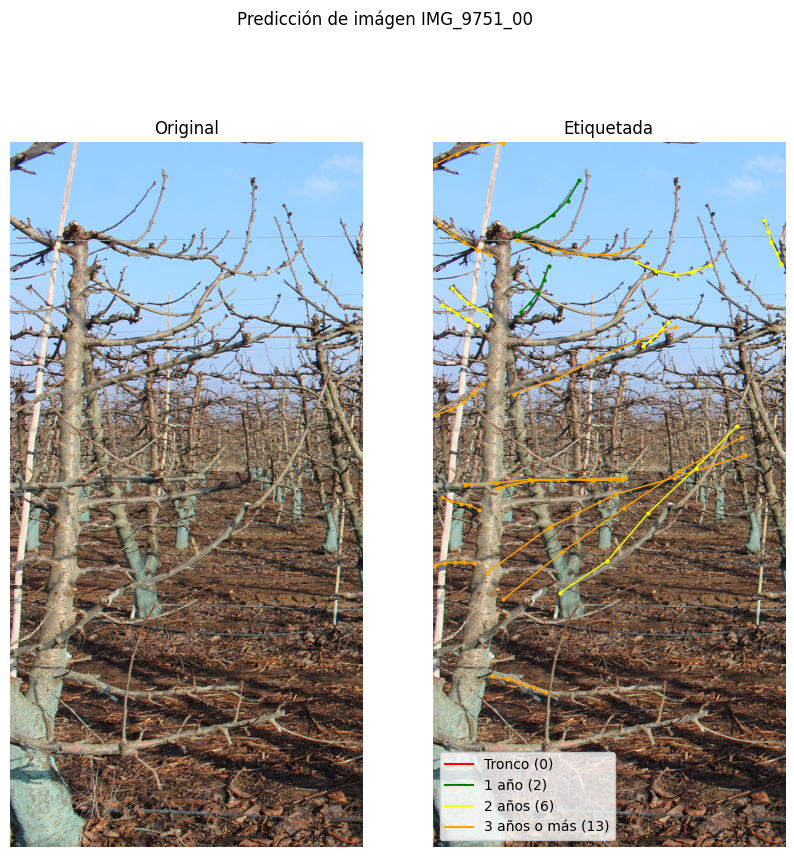

In [96]:
predictImage(model,path+'/data/test/images/IMG_9751_00.JPG')

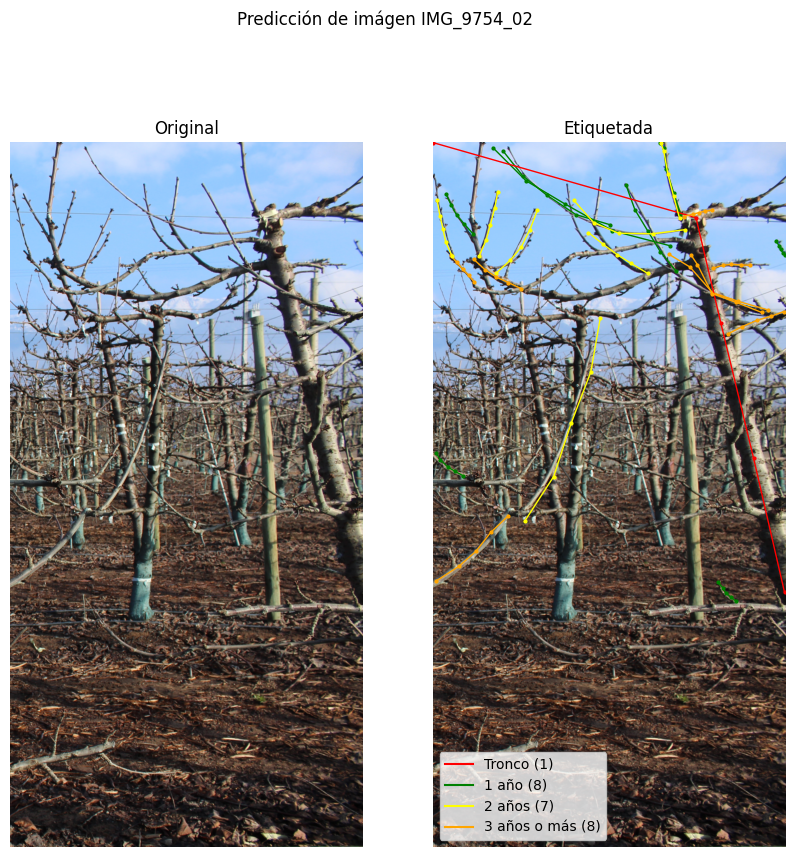

In [97]:
predictImage(model,path+'/data/test/images/IMG_9754_02.JPG')

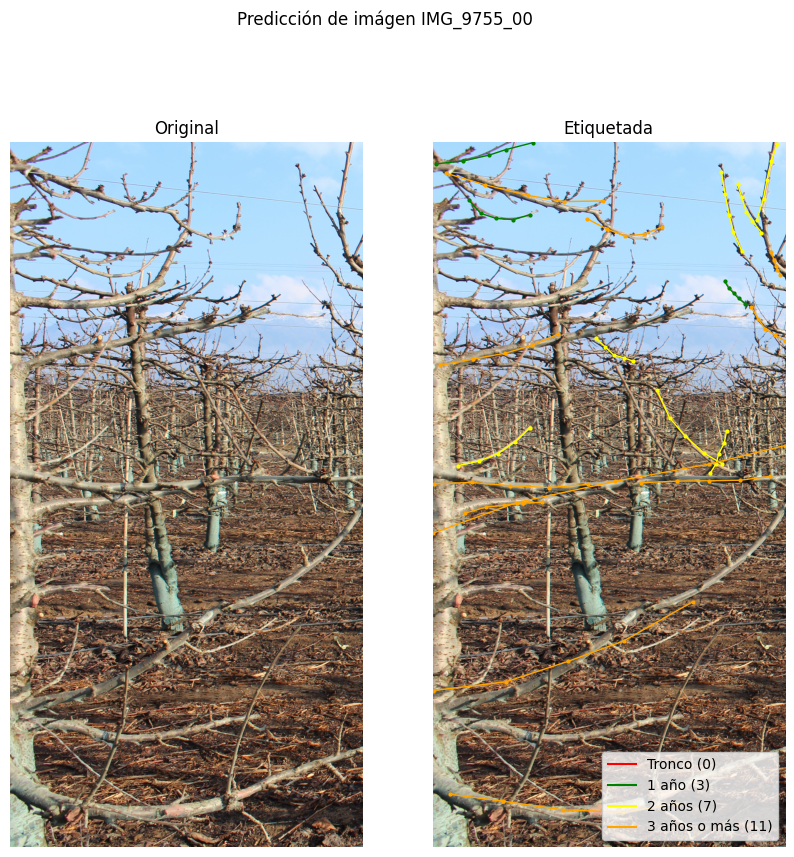

In [98]:
predictImage(model,path+'/data/test/images/IMG_9755_00.JPG')

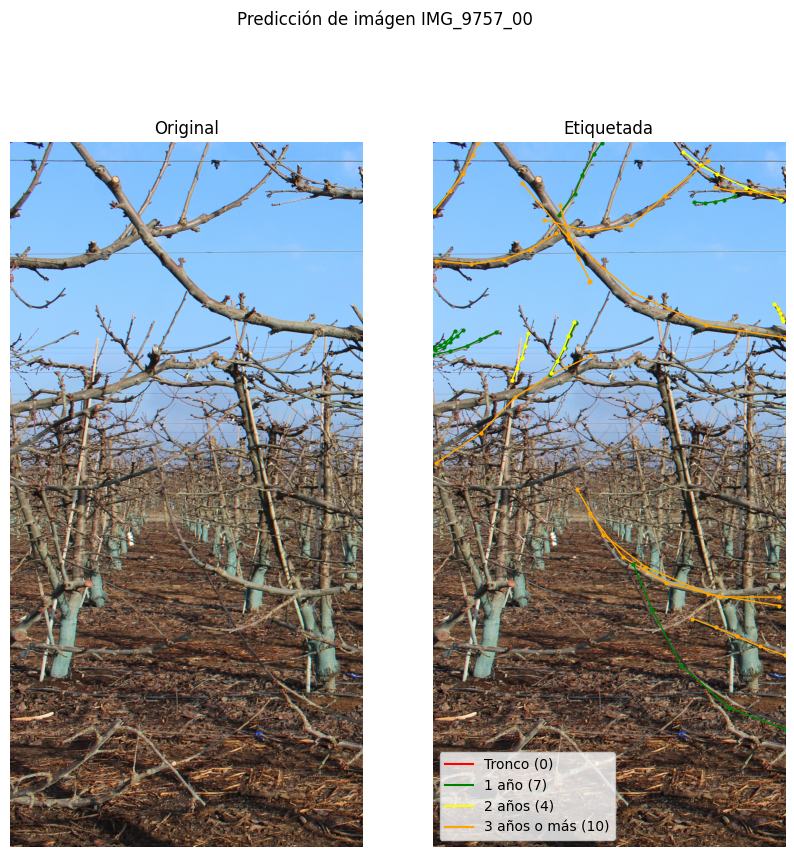

In [99]:
predictImage(model,path+'/data/test/images/IMG_9757_00.JPG')